In [31]:
import numpy as np
from tqdm import tqdm  # while loading images it shows progress Bar
import matplotlib.pyplot as plt #for showing images
from PIL import Image #resize the image and converting to gray scale
import os #for loading images from a given path
from random import shuffle #for shuffling he images

In [32]:
#folder path which contains traning images and testing images
TRAIN_DIR = '/content/train'
TEST_DIR = '/content/test'

In [33]:
# we will resize all images with PIL to a dimension of 120 * 120
IMG_SIZE = 120
MODEL_NAME = 'NIKEvsADIDAS'

In [34]:
# this function takes img name as parameter --- #if image name contains ADIDAS it return [0,1],
                                                #If image name is NIKe it return[1,0] ,so that we can feed to neural network
def label_image(img):
    # Images are formatted as: ADIDAS_1, NIKE_3 ...
    word_label = img.split('_')[0]
    if word_label == 'NIKE': return [1,0] #one hot encoding
    elif word_label == 'ADIDAS': return [0,1] #one hot encoding

In [35]:
def create_train_data():
  train_data = []
  for img in tqdm(os.listdir(TRAIN_DIR)): #os load image names from training folder and gives to tqdm
    label = label_image(img)
    path = os.path.join(TRAIN_DIR,img)
  # PIL
    img = Image.open(path)
    img = img.convert('L')
    img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
  #Create composite image by blending images using a transparency mask...... Image
  # ANTIALIAS (a high-quality downsampling filter).
    train_data.append([np.array(img), np.array(label)])
  shuffle(train_data)
  #np.save('train_data.npy',train_data)
  return train_data

In [36]:
def process_test_data():
  test_data = []
  for img in tqdm(os.listdir(TEST_DIR)):
       path = os.path.join(TEST_DIR,img)
       if "DS_Store" not in path:
            img_num = img.split('_')[1]
            img = Image.open(path)
            img = img.convert('L')
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)
            test_data.append([np.array(img), img_num])
  shuffle(test_data)
  #np.save('test_data.npy', test_data)
  return test_data

In [37]:
train_data = create_train_data()

100%|██████████| 100/100 [00:00<00:00, 298.49it/s]


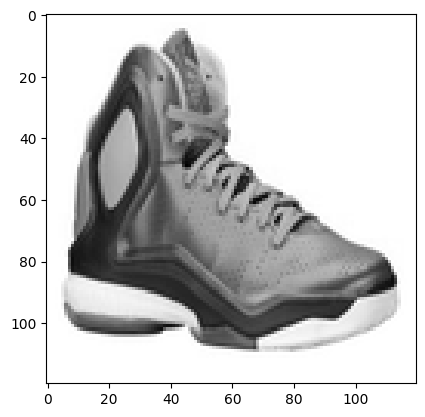

In [38]:
plt.imshow(train_data[1][0],cmap='gist_gray')
plt.show()

In [39]:
# BUILDING THE NETWORK

In [40]:
import keras
#sub module in tensor flow, import keras
# Imports the Keras deep learning library.
from keras.layers import Conv2D, MaxPooling2D
# Creates convolutional layers to extract image features.
# Reduces feature map size while keeping important features.
from keras.models import Sequential
# Creates a neural network by stacking layers sequentially.
from keras.layers import Dense, Dropout, Activation, Flatten
# Creates a fully connected (dense) layer.
# Randomly disables neurons during training to reduce overfitting.
# Applies an activation function like ReLU or Softmax or sigmoid to the output.
# Converts multi-dimensional feature maps into a 1D vector.

In [41]:
model = keras.Sequential()

model.add(Conv2D(16, 3, activation='relu', input_shape=(120,120,1)))  # 16 = filters, 3 = kernel size
model.add(Conv2D(32, (5,5), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(32, 3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64, 3, activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(64, activation='relu'))  # 64 = neurons
model.add(Dropout(0.2))
model.add(Dense(2, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
x = np.array([i[0] for i in train_data], dtype=np.float32).reshape(-1, IMG_SIZE, IMG_SIZE, 1) # -1 = calculate total no of elements automatically
x = x / 255.0  #normalizes the image pixel values from 0–255 to 0–1, helping the CNN train faster and perform better.(not required)
Y = np.array([i[1] for i in train_data])


In [43]:
model.fit(x,Y,epochs=10)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4700 - loss: 0.7287
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5400 - loss: 0.7004
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5600 - loss: 0.6736
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7200 - loss: 0.6283
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 995ms/step - accuracy: 0.7400 - loss: 0.5877
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7800 - loss: 0.5223   
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8300 - loss: 0.4295
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8700 - loss: 0.3470
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.8600 - loss: 0.3264
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9400 - loss: 0.2212


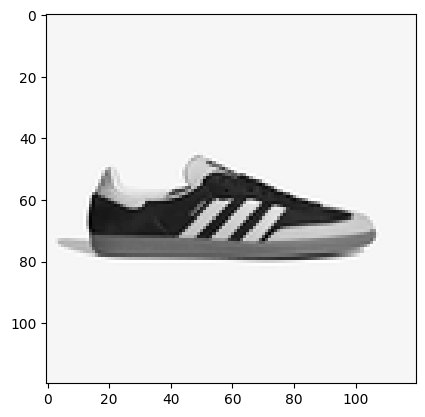

In [44]:
#PTL
img = Image.open('/content/adidas.webp')
img = img.convert('L')
img = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.LANCZOS)

plt.imshow(np.array(img), cmap = 'gist_gray')
plt.show()

In [45]:
model.predict(np.array(img).reshape(-1, IMG_SIZE, IMG_SIZE, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


array([[1., 0.]], dtype=float32)